
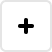
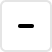
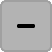
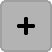
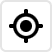
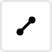
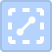
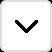
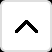
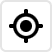
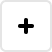
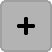
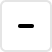
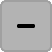
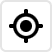
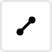
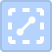
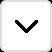
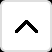
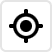

In [1]:
import numpy as np
import pandas as pd

from lets_plot import *

# offline=True embeds the JS bundle that ships with the locally built wheel.
# A dev build (4.8.3.devN) is not on the CDN, so the connected mode would have nothing to load.
LetsPlot.setup_html(offline=True)

In [2]:
# The registered style names (plot-builder/.../defaultTheme/RendererStyles.kt).
# Adding a style there makes it appear here with no other change.
STYLES = ['crisp', 'xkcd']


def styles(p, w=290, h=210):
    """Render one plot spec once per renderer style, side by side.

    The plot `p` carries NO renderer of its own: the same spec goes through every style,
    which is the whole point — a geom cannot tell which renderer will draw it.
    """
    return gggrid(
        [p + theme(renderer=s) + ggtitle(s) + ggsize(w, h) for s in STYLES],
        ncol=len(STYLES),
    )

In [3]:
penguins = pd.read_csv('penguins.csv').dropna().sort_values('bill_length_mm')

# Per-species summary — feeds the interval geoms (errorbar / linerange / pointrange / crossbar / lollipop).
summ = penguins.groupby('species', as_index=False).agg(m=('body_mass_g', 'mean'), s=('body_mass_g', 'std'))
summ['ymin'] = summ['m'] - summ['s']
summ['ymax'] = summ['m'] + summ['s']

# A binned ordered series — feeds the path / ribbon / step family.
# (drop the Interval bin column: pandas' interval dtype is not a plottable type)
band = (penguins.assign(_b=pd.cut(penguins['bill_length_mm'], bins=16))
        .groupby('_b', as_index=False, observed=True)
        .agg(x=('bill_length_mm', 'mean'), m=('body_mass_g', 'mean'), s=('body_mass_g', 'std'))
        .drop(columns='_b')
        .dropna())
band['ymin'] = band['m'] - band['s']
band['ymax'] = band['m'] + band['s']

penguins.head(3)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
142,Adelie,Dream,32.1,15.5,188.0,3050.0,female
98,Adelie,Dream,33.1,16.1,178.0,2900.0,female
70,Adelie,Torgersen,33.5,19.0,190.0,3600.0,female


In [4]:
# geom_path — connects points in data order
styles(ggplot(band, aes('x', 'm')) + geom_path(size=1))

In [5]:
# geom_line — like path, but ordered by x
styles(ggplot(penguins, aes('bill_length_mm', 'flipper_length_mm')) + geom_line(size=1))

In [6]:
# geom_step — step interpolation
styles(ggplot(band, aes('x', 'm')) + geom_step(size=1))

In [7]:
# geom_segment with arrowheads — shafts distort, tips stay crisp
seg = pd.DataFrame({'x': [0, 1, 2], 'y': [0, 0, 0], 'xend': [1, 2, 3], 'yend': [2, 1, 3]})
styles(ggplot(seg) + geom_segment(aes('x', 'y', xend='xend', yend='yend'), arrow=arrow(), size=1))

In [8]:
# geom_curve — pre-densified into a polyline before it reaches the renderer
styles(ggplot() + geom_curve(x=0, y=0, xend=3, yend=2, curvature=0.5, arrow=arrow(), size=1))

In [9]:
# geom_spoke — segments from angle + radius
grid_df = pd.DataFrame([(x, y) for x in range(5) for y in range(5)], columns=['x', 'y'])
grid_df['angle'] = np.arctan2(grid_df['y'] - 2, grid_df['x'] - 2)
styles(ggplot(grid_df, aes('x', 'y')) + geom_spoke(aes(angle='angle'), radius=0.6, size=0.8))

In [10]:
# geom_hline / geom_vline / geom_abline — reference lines distort too
styles(ggplot(penguins, aes('bill_length_mm', 'body_mass_g'))
       + geom_point(color='gray')
       + geom_hline(yintercept=4200, color='#d73027', size=1)
       + geom_vline(xintercept=45, color='#1a9850', size=1)
       + geom_abline(slope=100, intercept=-200, color='#4575b4', size=1))

In [11]:
# geom_area (density)
styles(ggplot(penguins, aes('flipper_length_mm'))
       + geom_area(stat='density', fill='#4575b4', color='black', alpha=0.5))

In [12]:
# geom_density with quantile lines
styles(ggplot(penguins, aes('body_mass_g'))
       + geom_density(quantile_lines=True, quantiles=[0.25, 0.5, 0.75],
                      fill='#91bfdb', color='black', alpha=0.4))

In [13]:
# geom_ribbon — band between ymin and ymax
styles(ggplot(band, aes('x'))
       + geom_ribbon(aes(ymin='ymin', ymax='ymax'), fill='#4575b4', color='black', alpha=0.4))

In [14]:
# geom_band — bands spanning the panel
styles(ggplot(penguins, aes('bill_length_mm', 'body_mass_g'))
       + geom_band(aes(ymin='ymin', ymax='ymax', fill='species'), data=summ, color='black', alpha=0.3)
       + geom_point(size=1.5))

In [15]:
# geom_area_ridges — the densest band source (simplified outline, see LinesHelper.createBandData)
styles(ggplot(penguins, aes('body_mass_g', 'species', fill='species')) + geom_area_ridges())

In [16]:
# geom_smooth — fitted line over a confidence ribbon
styles(ggplot(penguins, aes('bill_length_mm', 'body_mass_g')) + geom_point(size=1.5) + geom_smooth())

In [17]:
# geom_violin with quantile lines
styles(ggplot(penguins, aes('species', 'body_mass_g', fill='species')) + geom_violin(quantile_lines=True))

In [18]:
# geom_sina — points spread by local density (point glyphs stay crisp, see below)
styles(ggplot(penguins, aes('species', 'body_mass_g', color='species')) + geom_sina())

In [19]:
# geom_polygon — each ring distorted on its own
triangles = pd.DataFrame({'x': [0, 1, 0.5] * 2, 'y': [0, 0, 1] * 2, 'g': ['A'] * 3 + ['B'] * 3})
styles(ggplot(triangles, aes('x', 'y', group='g', fill='g'))
       + geom_polygon(color='black', size=1, alpha=0.6))

In [20]:
# geom_rect — note the xkcd corner fillet
rects = pd.DataFrame({'xmin': [0, 2, 4], 'xmax': [1.5, 3.5, 5.5],
                      'ymin': [0, 1, 0.5], 'ymax': [2, 3, 2.5], 'g': ['a', 'b', 'c']})
styles(ggplot(rects) + geom_rect(aes(xmin='xmin', xmax='xmax', ymin='ymin', ymax='ymax', fill='g'),
                                 color='black', alpha=0.6))

In [21]:
# geom_bar
styles(ggplot(penguins, aes('species', fill='island')) + geom_bar())

In [22]:
# geom_tile
tile_df = penguins.groupby(['island', 'species'], as_index=False).agg(m=('body_mass_g', 'mean'))
styles(ggplot(tile_df, aes('species', 'island', fill='m')) + geom_tile(color='black'))

In [23]:
# geom_bin2d — inherits the tile draw path
styles(ggplot(penguins, aes('bill_length_mm', 'flipper_length_mm')) + geom_bin2d())

In [24]:
# geom_boxplot
styles(ggplot(penguins, aes('species', 'body_mass_g', fill='species')) + geom_boxplot())

In [25]:
# geom_crossbar — the midline is drawn through the renderer too
styles(ggplot(summ, aes('species'))
       + geom_crossbar(aes(y='m', ymin='ymin', ymax='ymax', fill='species'), alpha=0.5))

In [26]:
# geom_errorbar
styles(ggplot(summ, aes('species'))
       + geom_errorbar(aes(ymin='ymin', ymax='ymax', color='species'), width=0.3, size=1))

In [27]:
# geom_linerange
styles(ggplot(summ, aes('species'))
       + geom_linerange(aes(ymin='ymin', ymax='ymax', color='species'), size=1))

In [28]:
# geom_pointrange — the range distorts, the point glyph stays crisp
styles(ggplot(summ, aes('species'))
       + geom_pointrange(aes(y='m', ymin='ymin', ymax='ymax', color='species'), size=1))

In [29]:
# geom_lollipop
styles(ggplot(summ, aes('species', 'm')) + geom_lollipop(aes(color='species'), size=2))

In [30]:
# geom_point — identical across all three styles by design (chrome around it is not)
styles(ggplot(penguins, aes('bill_length_mm', 'flipper_length_mm', color='species')) + geom_point(size=4))

In [31]:
# geom_dotplot / geom_ydotplot — dot glyphs stay crisp, the axis and grid around them do not
styles(ggplot(penguins, aes('flipper_length_mm')) + geom_dotplot(binwidth=2))

In [32]:
styles(ggplot(penguins, aes('species', 'flipper_length_mm')) + geom_ydotplot(binwidth=2))

In [33]:
# geom_pie
styles(ggplot(penguins, aes(fill='island')) + geom_pie(size=15, hole=0.3, color='black'))

In [34]:
# geom_hex — every hexagon distorts independently
styles(ggplot(penguins, aes('bill_length_mm', 'flipper_length_mm')) + geom_hex())

In [35]:
# geom_text / geom_label — the font is a theme-overlay value owned by the style entry
txt = pd.DataFrame({'x': [1, 2, 3], 'y': [1, 2, 1.6], 't': ['one', 'two', 'three']})
styles(ggplot(txt, aes('x', 'y', label='t'))
       + geom_point(size=3)
       + geom_text(size=9, nudge_y=0.25)
       + geom_label(size=7, nudge_y=-0.25))

In [36]:
# geom_text_repel — the leader lines are drawn through the renderer, the glyphs stay crisp
labels = penguins.drop_duplicates('species')
styles(ggplot(penguins, aes('bill_length_mm', 'flipper_length_mm'))
       + geom_point(color='gray', size=1.5)
       + geom_text_repel(aes(label='species'), data=labels, size=7, seed=42))

In [37]:
# geom_bracket — bracket lines distort, the label rides the style's font
bracket_df = pd.DataFrame({'xmin': ['Adelie'], 'xmax': ['Gentoo'], 'y': [6500], 'label': ['p < 0.05']})
styles(ggplot(penguins, aes('species', 'body_mass_g'))
       + geom_boxplot(aes(fill='species'), alpha=0.3)
       + geom_bracket(aes(xmin='xmin', xmax='xmax', y='y', label='label'), data=bracket_df))

In [38]:
# Axis line, grid, legend frame — all three styles, all chrome adapts
styles(ggplot(penguins, aes('bill_length_mm', 'body_mass_g', color='species'))
       + geom_point(size=3)
       + theme(legend_position='right'),
       w=320, h=240)

In [39]:
# Colorbar frame (continuous legend)
styles(ggplot(penguins, aes('bill_length_mm', 'body_mass_g', color='body_mass_g')) + geom_point(size=3),
       w=320, h=240)

In [40]:
# Polar coords: the grid distorts, the polar axis stays crisp (CRISP exemption).
styles(ggplot(summ, aes('species', 'm', fill='species'))
       + geom_bar(stat='identity')
       + coord_polar(),
       w=300, h=260)

In [41]:
styles(ggplot(penguins, aes('bill_length_mm', 'body_mass_g', color='species'))
       + geom_point(size=4, tooltips=layer_tooltips().line('@species').line('mass|@body_mass_g')),
       w=320, h=240)

In [42]:
p1 = ggplot(penguins, aes('bill_length_mm', 'body_mass_g')) + geom_line(size=1) + ggtitle('inherited')
p2 = (ggplot(penguins, aes('species', fill='species')) + geom_bar()
      + theme_classic() + ggtitle('own theme, still inherits'))
gggrid([p1, p2], ncol=2) + theme(renderer='xkcd') + ggsize(700, 260)

In [43]:
p = ggplot(penguins, aes('species', 'body_mass_g', fill='species')) + geom_boxplot()
gggrid([
    p + theme(renderer='xkcd') + ggtitle("xkcd — overlay font"),
    p + theme(renderer='xkcd', text=element_text(family='Georgia')) + ggtitle('user font wins'),
], ncol=2) + ggsize(700, 260)

In [44]:
p = (ggplot(penguins, aes('bill_length_mm', 'body_mass_g', color='species'))
     + geom_point(size=3) + geom_smooth(se=False))
gggrid([p + theme(renderer=s) + flavor_high_contrast_dark() + ggtitle(s) + ggsize(290, 210)
        for s in STYLES], ncol=3)

In [45]:
# iter9 — interactive pan check for the uniform wobble seed.
# Drag to pan (toolbar via ggtb): each geom's xkcd wobble should ride WITH the shape,
# not re-randomize ("boil") frame to frame. Zoom reorganizes the wobble but also doesn't boil.
(ggplot(band, aes('x', 'm'))
 + geom_area(fill='#a1d99b', color='#31a354', alpha=0.5, size=1)
 + geom_line(size=1.2, color='#2b8cbe')
 + geom_point(size=3, color='#2b8cbe')
 + theme(renderer='xkcd')
 + ggsize(900, 500)
 + ggtb())